# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset and explore the dataset
df = pd.read_csv('data_banknote_authentication.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

First 5 rows:
   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0

Dataset sha

In [2]:
X = df.drop('Class',axis=1)
y = df['Class']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [3]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
base_pred = model.predict(X_test)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

operations = [
    ('scaler', StandardScaler()),
    ('DTC', DecisionTreeClassifier())
]

pipe = Pipeline(operations)

param_grid = {
    'DTC__max_leaf_nodes': list(range(2,20))
}

full_search = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=3)

full_search.fit(X_train, y_train)

print(full_search.best_params_)

{'DTC__max_leaf_nodes': 15}


Confusion Matrix:
[[231   7]
 [  1 173]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       238
           1       0.96      0.99      0.98       174

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412



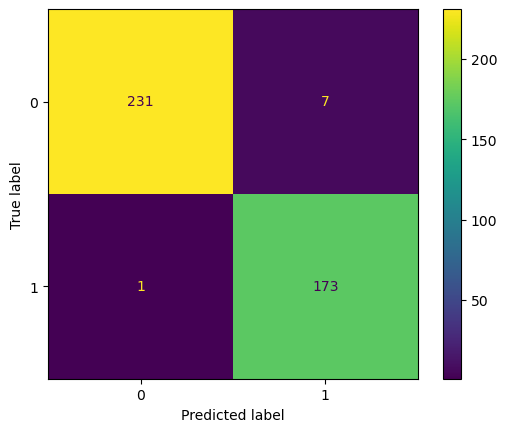

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Your predictions
#base_pred = model.predict(X_test)  # replace 'model' with your actual model

# Print confusion matrix as numbers
print("Confusion Matrix:")
print(confusion_matrix(y_test, base_pred))

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, base_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, base_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

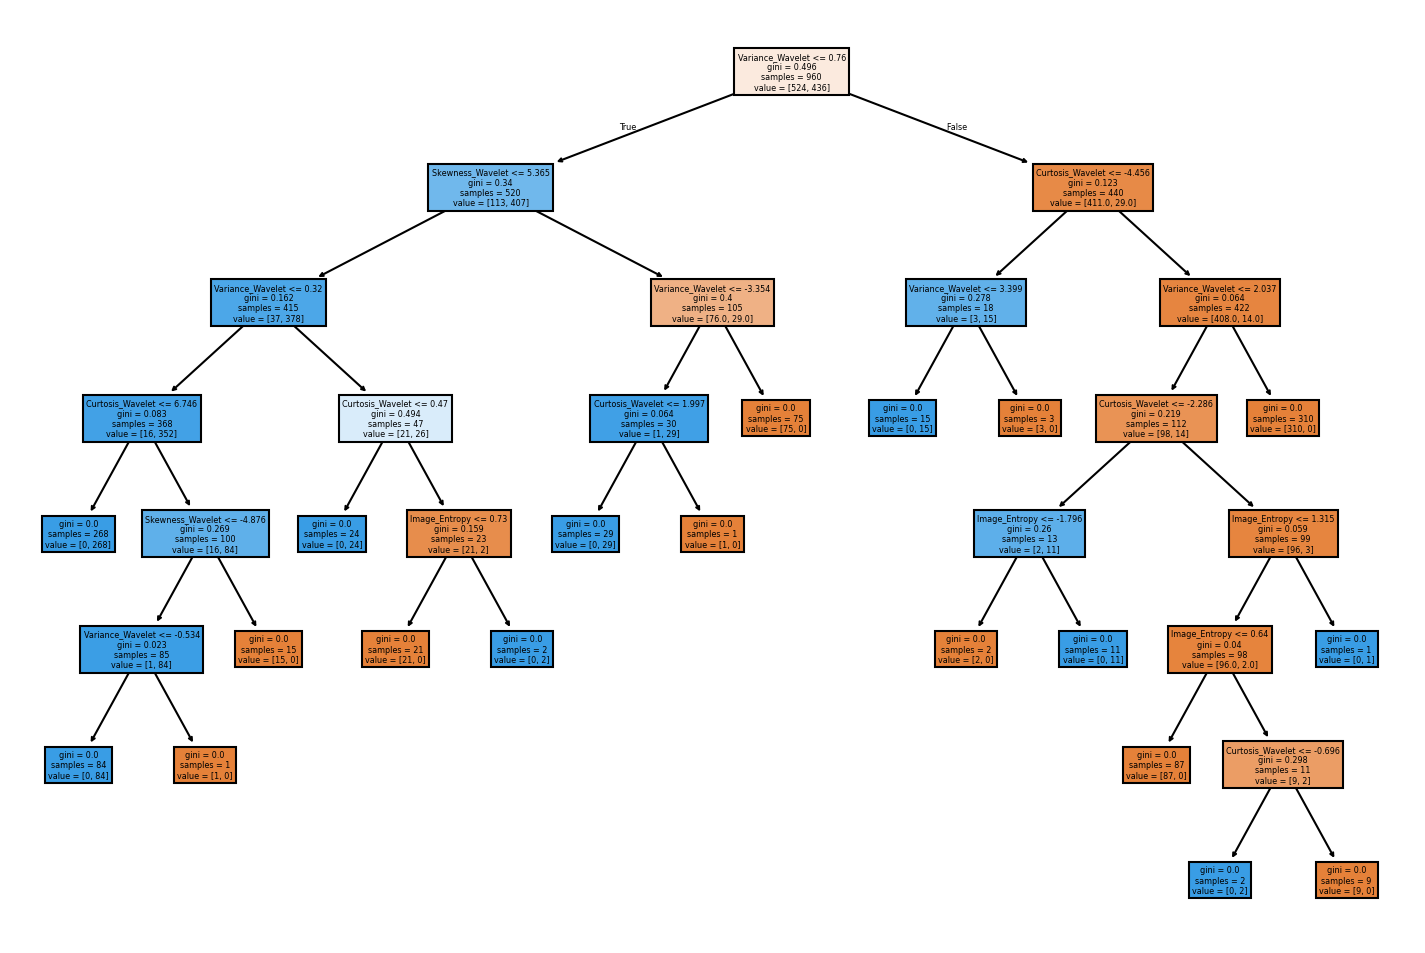

In [6]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns);

In [7]:
######################################### Random Forest #############################################

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
preds = model.predict(X_test)

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

operations = [
    ('scaler', StandardScaler()),
    ('RFC', RandomForestClassifier())
]

pipe = Pipeline(operations)

param_grid = {
    'RFC__max_leaf_nodes': list(range(2,20))
}

full_search = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=3)

full_search.fit(X_train, y_train)

print(full_search.best_params_)

{'RFC__max_leaf_nodes': 18}


In [15]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
confusion_matrix(y_test,preds)

array([[235,   3],
       [  0, 174]])


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       238
           1       0.96      0.99      0.98       174

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412



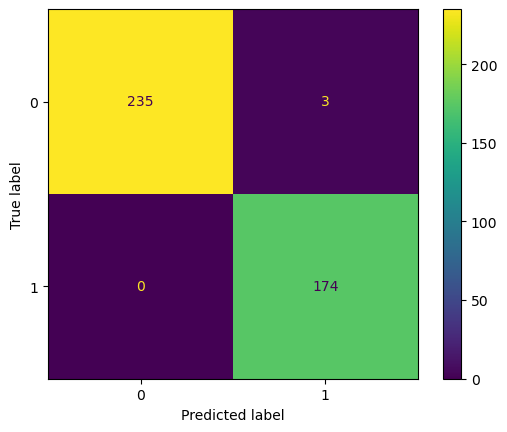

In [16]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, base_pred))


In [13]:
# According to the results of both mthods, it can be infered that the solutions are similar despite the method
# the cross validation results show two different result, indicating that with a smaller CV, we get a better Confusion matrix when we talk
# about the random forst algorithm
# beside this difference, the classification report shows two similar results